In [3]:
# ==========================================
# CODE 2 / NOTEBOOK 2
# INCIDENT TAXONOMY AND CATEGORY STRUCTURE
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
# -----------------------------
# 1. LOAD CLEANED DATA
# -----------------------------
df = pd.read_csv("occurrences_cleaned.csv")
df.head()

,occurrence_id,local_date_main_event,date_main_event_unconfirmed,year_reported,occurrence_severity,main_event_l1,main_event_l2,main_event_l3,not_vessel_operations,short_description,description,national_keywords,emcip_keywords,sar_intervention,state_reporting,occurrence_location,coastal_state_affected,national_location_l1,national_location_l2,latitude,longitude,lat_long_unknown,port_of_accident_l1,port_of_accident_l2,natural_light,sea_state,visibility,weather,wind_force,publication_date,publication_no,publication_type,published_report_website_link,occurrence_record_modified_on,last_updated_at,occurrences_reported_from,occurrences_reported_to
0,1f59ae23-e48f-ec11-b400-000d3a874c7b,2022-02-01,No,2022,Marine Incident,Contact,Shore Object,NaN,False,A ro-ro cargo vessel made contact with quay side,A ro-ro cargo vessel was manoeuvring to line up to enter a lock when the vessel made contact with the eastern approach causing damage to at least two fenders. A tug was assisting the vessel.,NaN,NaN,No,UK,Internal waters -> Port area,UNITED KINGDOM,United Kingdom,England,53.6383,-0.199300,NaN,UNITED KINGDOM,Immingham,Unknown,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-01-29,2026-05-15,2020-01-01,2025-12-31
1,c51366b7-39cd-ec11-a7b6-0022481a81f8,2022-04-01,No,2022,Marine Incident,Damage / Loss Of Equipment,NaN,NaN,False,A service vessel drifted from a quayside resulting in a gangway falling into the water,A service vessel entered a port through lock gates and came alongside with a tie up of a breast line forward and aft. A gangway was then deployed. The vessel started to drift astern with the bow c...,NaN,NaN,No,UK,Internal waters -> Port area,UNITED KINGDOM,United Kingdom,Scotland,55.9869,-3.176900,NaN,UNITED KINGDOM,Leith,Daylight,1 - Calm rippled - (0 - 0.1 m),Good - 5.0 <= Vis < 25.0 nm,Clear,4 - Moderate Breeze - knot (11-16) m/s (6-8),NaN,NaN,NaN,NaN,2025-03-28,2026-05-15,2020-01-01,2025-12-31
2,883d7a39-90e1-ec11-bb3d-000d3a0cda10,2022-05-01,No,2022,Marine Incident,Accident to person(s),NaN,NaN,False,A inland passenger vessel passenger fell down stairs resulting in a head laceration,An inland waterways passenger vessel passenger fell whilst onboard resulting in a head injury. The passenger refused assistance from an ambulance and made their own way to hospital.,NaN,NaN,No,UK,Inland waters -> River,UNITED KINGDOM,United Kingdom,England,51.5074,-0.082500,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-03-13,2026-05-15,2020-01-01,2025-12-31
3,68afeb11-12ee-ec11-bb3c-000d3a0d2897,2022-06-01,No,2022,Marine Incident,Loss Of Control,Loss Of Propulsion Power,NaN,False,Fishing vessel's gearbox failed resulting in a tow.,Fishing vessel's gearbox failed resulting in a tow from another fishing vessel. The casualty vessel was not in danger at any point.,NaN,NaN,No,UK,Open sea -> Within EEZ,None/Register withdrawn,NaN,NaN,50.0644,-3.417183,NaN,NaN,NaN,Daylight,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-01-29,2026-05-15,2020-01-01,2025-12-31
4,d40d9f19-bd0c-ed11-b83d-0022481b1890,2022-07-01,No,2022,Less Serious,Accident to person(s),NaN,NaN,False,A sailing yacht crew member sustained a partial amputation to two fingers,"A sailing yacht was seeking shelter as the wind was due, the crew set about stowing the sails. The furling gear had loosened, a crew member went forward to furl the genoa. As they rotated the furl...",NaN,NaN,Yes,UK,Coastal waters <= 12 nm,UNITED KINGDOM,United Kingdom,Scotland,56.2847,-6.243700,NaN,NaN,NaN,Daylight,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-02-23,2026-05-15,2020-01-01,2025-12-31


In [5]:
# -----------------------------
# 2. BASIC PREPARATION
# -----------------------------
df["local_date_main_event"] = pd.to_datetime(df["local_date_main_event"], errors="coerce")
df["event_year"] = df["local_date_main_event"].dt.year

for col in ["main_event_l1", "main_event_l2", "main_event_l3", "occurrence_severity"]:
    df[col] = df[col].astype("string").str.strip()

print("Dataset shape:", df.shape)
print("Unique L1 categories:", df["main_event_l1"].nunique())
print("Unique L2 categories:", df["main_event_l2"].nunique())
print("Unique L3 categories:", df["main_event_l3"].nunique())

Dataset shape: (8599, 38)
Unique L1 categories: 13
Unique L2 categories: 19
Unique L3 categories: 5


In [6]:
# -----------------------------
# 3. MISSINGNESS IN EVENT HIERARCHY
# -----------------------------
taxonomy_missing = df[["main_event_l1", "main_event_l2", "main_event_l3"]].isna().sum().reset_index()
taxonomy_missing.columns = ["level", "missing_count"]
taxonomy_missing["missing_pct"] = (taxonomy_missing["missing_count"] / len(df)) * 100

print("\n===== MISSINGNESS IN EVENT HIERARCHY =====")
print(taxonomy_missing)


===== MISSINGNESS IN EVENT HIERARCHY =====
           level  missing_count  missing_pct
0  main_event_l1              2     0.023259
1  main_event_l2           4351    50.598907
2  main_event_l3           8290    96.406559


In [7]:
# -----------------------------
# 4. MAIN EVENT LEVEL 1 DISTRIBUTION
# -----------------------------
l1_counts = (
    df["main_event_l1"]
    .value_counts(dropna=False)
    .reset_index()
)
l1_counts.columns = ["main_event_l1", "count"]
l1_counts["pct"] = (l1_counts["count"] / len(df)) * 100

print("\n===== MAIN EVENT L1 DISTRIBUTION =====")
print(l1_counts)


===== MAIN EVENT L1 DISTRIBUTION =====
                 main_event_l1  count        pct
0        Accident to person(s)   2381  27.689266
1   Damage / Loss Of Equipment   1910  22.211885
2              Loss Of Control   1342  15.606466
3        Grounding / Stranding    866  10.070938
4                      Contact    640   7.442726
5                    Collision    526    6.11699
6             Fire / Explosion    462   5.372718
7        Flooding / Foundering    296   3.442261
8          Capsizing / Listing    157   1.825794
9                 Hull Failure     10   0.116293
10        Heavy Weather Damage      3   0.034888
11        Non-accidental Event      3   0.034888
12                        <NA>      2   0.023259
13                     Missing      1   0.011629


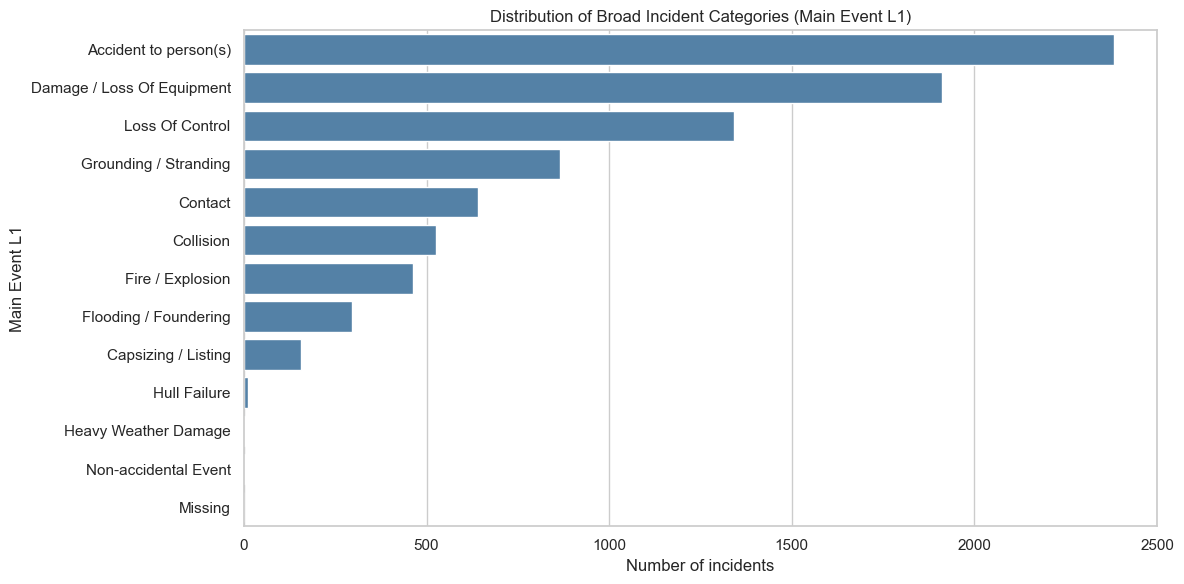

In [8]:
# -----------------------------
# 5. PLOT: TOP LEVEL 1 INCIDENT CATEGORIES
# -----------------------------
plt.figure(figsize=(12, 6))
sns.barplot(
    data=l1_counts.head(15),
    y="main_event_l1",
    x="count",
    color="steelblue"
)
plt.title("Distribution of Broad Incident Categories (Main Event L1)")
plt.xlabel("Number of incidents")
plt.ylabel("Main Event L1")
plt.tight_layout()
plt.show()

In [9]:
# -----------------------------
# 6. MAIN EVENT LEVEL 2 DISTRIBUTION
# -----------------------------
l2_counts = (
    df["main_event_l2"]
    .dropna()
    .value_counts()
    .reset_index()
)
l2_counts.columns = ["main_event_l2", "count"]
l2_counts["pct"] = (l2_counts["count"] / len(df.dropna(subset=["main_event_l2"]))) * 100

print("\n===== TOP 20 MAIN EVENT L2 CATEGORIES =====")
print(l2_counts.head(20))


===== TOP 20 MAIN EVENT L2 CATEGORIES =====
                  main_event_l2  count        pct
0      Loss Of Propulsion Power    959   22.57533
1                         Power    609  14.336158
2                  Shore Object    505  11.887947
3                          Fire    418   9.839925
4               With Other Ship    366   8.615819
5                      Flooding    241   5.673258
6                         Drift    225    5.29661
7   Loss Of Directional Control    170   4.001883
8                     Capsizing    149   3.507533
9             Ship Not Underway    138   3.248588
10              Floating Object    131   3.083804
11     Loss Of Electrical Power    118   2.777778
12          Loss Of Containment     93   2.189266
13                   Foundering     55   1.294727
14                    Explosion     40    0.94162
15          With Multiple Ships     20    0.47081
16                      Listing      7   0.164783
17                        Other      2   0.047081
18   

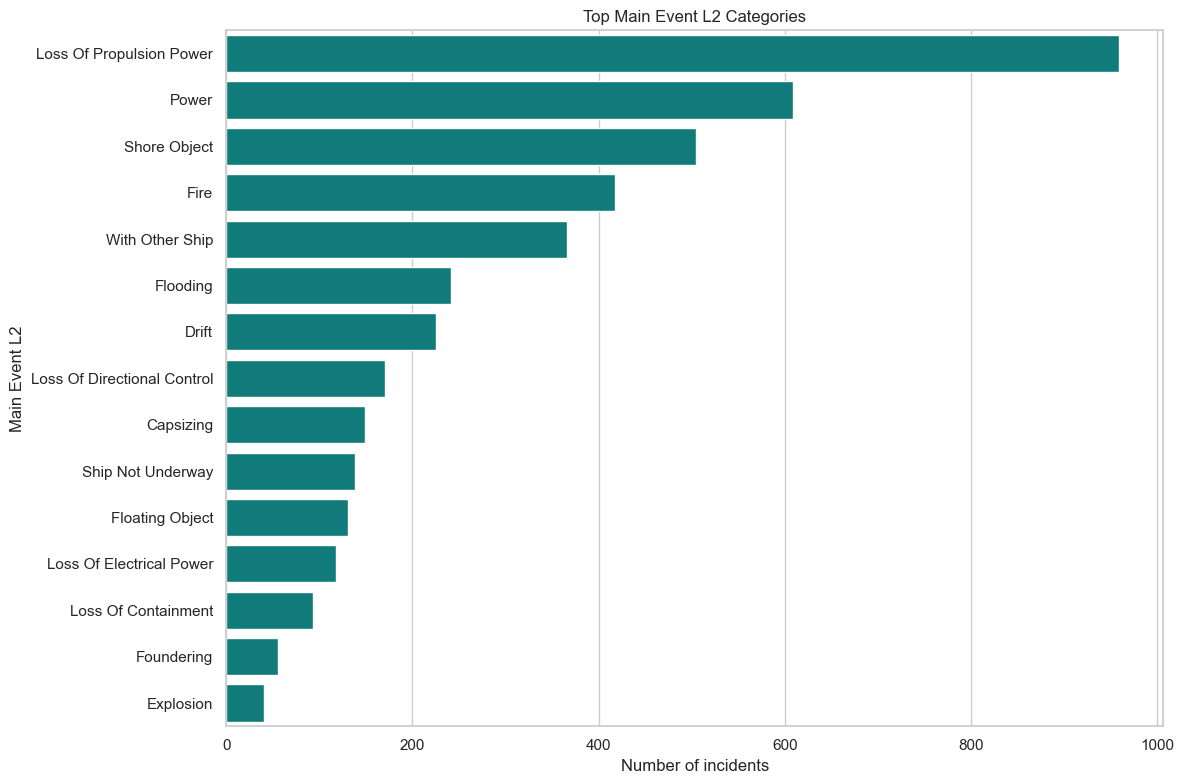

In [10]:
# -----------------------------
# 7. PLOT: TOP LEVEL 2 INCIDENT CATEGORIES
# -----------------------------
plt.figure(figsize=(12, 8))
sns.barplot(
    data=l2_counts.head(15),
    y="main_event_l2",
    x="count",
    color="darkcyan"
)
plt.title("Top Main Event L2 Categories")
plt.xlabel("Number of incidents")
plt.ylabel("Main Event L2")
plt.tight_layout()
plt.show()

In [11]:
# -----------------------------
# 8. MAIN EVENT LEVEL 3 DISTRIBUTION
# -----------------------------
l3_counts = (
    df["main_event_l3"]
    .dropna()
    .value_counts()
    .reset_index()
)
l3_counts.columns = ["main_event_l3", "count"]
l3_counts["pct"] = (l3_counts["count"] / len(df.dropna(subset=["main_event_l3"]))) * 100

print("\n===== TOP 20 MAIN EVENT L3 CATEGORIES =====")
print(l3_counts.head(20))


===== TOP 20 MAIN EVENT L3 CATEGORIES =====
  main_event_l3  count        pct
0   Progressive    198   64.07767
1         Other     66  21.359223
2       Unknown     27   8.737864
3       Massive     17   5.501618
4         Cargo      1   0.323625


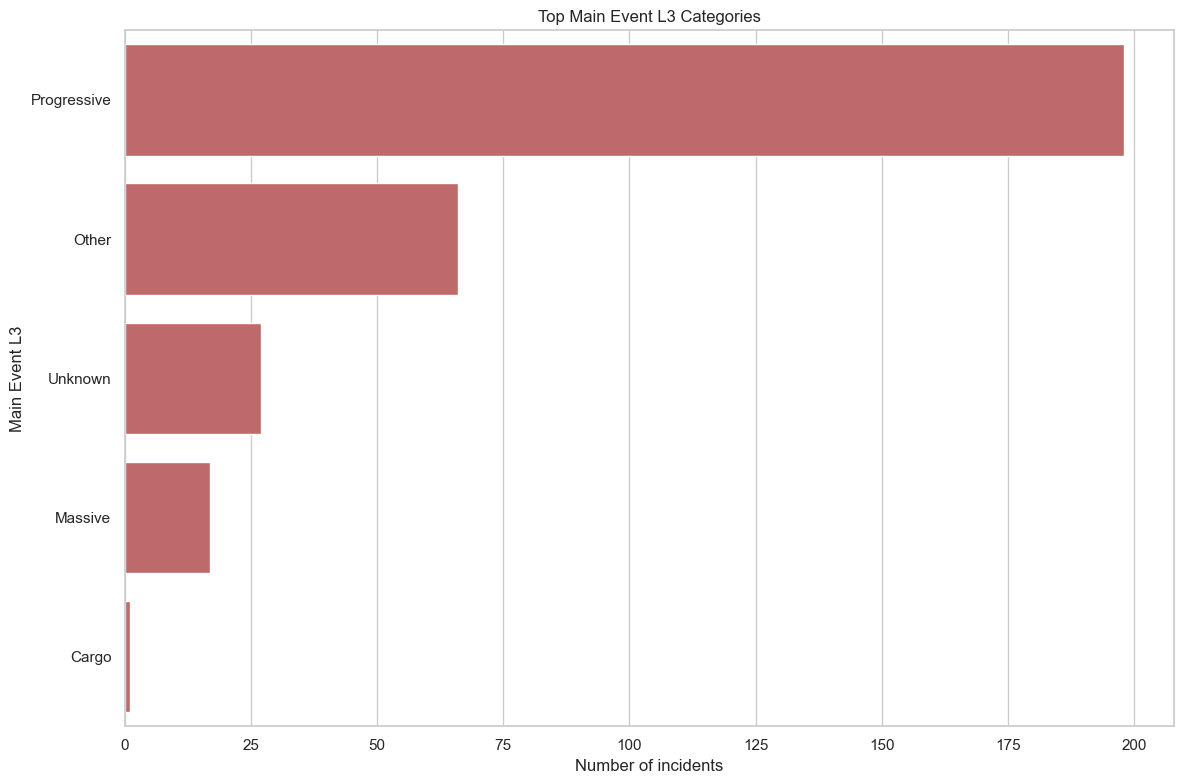

In [12]:
# -----------------------------
# 9. PLOT: TOP LEVEL 3 INCIDENT CATEGORIES
# -----------------------------
plt.figure(figsize=(12, 8))
sns.barplot(
    data=l3_counts.head(15),
    y="main_event_l3",
    x="count",
    color="indianred"
)
plt.title("Top Main Event L3 Categories")
plt.xlabel("Number of incidents")
plt.ylabel("Main Event L3")
plt.tight_layout()
plt.show()

In [13]:
# -----------------------------
# 10. L1 -> L2 TAXONOMY TABLE
# -----------------------------
l1_l2_counts = (
    df.dropna(subset=["main_event_l1", "main_event_l2"])
    .groupby(["main_event_l1", "main_event_l2"])
    .size()
    .reset_index(name="count")
    .sort_values(["main_event_l1", "count"], ascending=[True, False])
)

print("\n===== TOP L2 WITHIN EACH L1 =====")
print(l1_l2_counts.head(30))


===== TOP L2 WITHIN EACH L1 =====
            main_event_l1                main_event_l2  count
0     Capsizing / Listing                    Capsizing    149
1     Capsizing / Listing                      Listing      7
4               Collision              With Other Ship    366
2               Collision            Ship Not Underway    138
3               Collision          With Multiple Ships     20
7                 Contact                 Shore Object    505
5                 Contact              Floating Object    131
6                 Contact                Flying Object      2
9        Fire / Explosion                         Fire    418
8        Fire / Explosion                    Explosion     40
10  Flooding / Foundering                     Flooding    241
11  Flooding / Foundering                   Foundering     55
13  Grounding / Stranding                        Power    609
12  Grounding / Stranding                        Drift    225
17        Loss Of Control     Loss 

In [14]:
# -----------------------------
# 11. TOP 3 L2 CATEGORIES WITHIN EACH L1
# -----------------------------
top_l2_within_l1 = (
    l1_l2_counts
    .groupby("main_event_l1")
    .head(3)
    .reset_index(drop=True)
)

print("\n===== TOP 3 L2 CATEGORIES WITHIN EACH L1 =====")
print(top_l2_within_l1)


===== TOP 3 L2 CATEGORIES WITHIN EACH L1 =====
            main_event_l1                main_event_l2  count
0     Capsizing / Listing                    Capsizing    149
1     Capsizing / Listing                      Listing      7
2               Collision              With Other Ship    366
3               Collision            Ship Not Underway    138
4               Collision          With Multiple Ships     20
5                 Contact                 Shore Object    505
6                 Contact              Floating Object    131
7                 Contact                Flying Object      2
8        Fire / Explosion                         Fire    418
9        Fire / Explosion                    Explosion     40
10  Flooding / Foundering                     Flooding    241
11  Flooding / Foundering                   Foundering     55
12  Grounding / Stranding                        Power    609
13  Grounding / Stranding                        Drift    225
14        Loss Of Cont

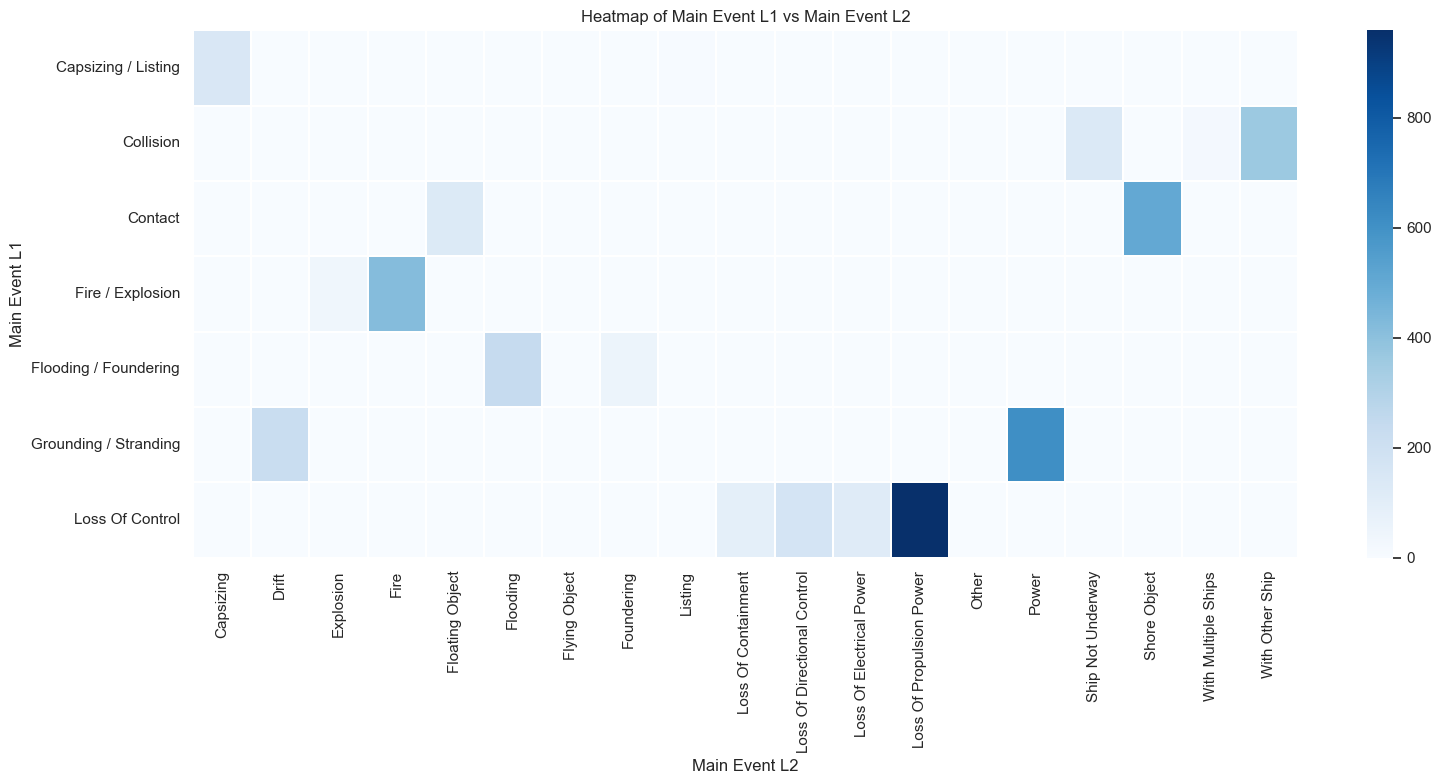

In [15]:
# -----------------------------
# 12. L1 -> L2 HEATMAP TABLE
# -----------------------------
l1_l2_pivot = (
    df.dropna(subset=["main_event_l1", "main_event_l2"])
    .groupby(["main_event_l1", "main_event_l2"])
    .size()
    .unstack(fill_value=0)
)

# keep only major L1 rows for readability
major_l1 = l1_counts[l1_counts["count"] >= 50]["main_event_l1"]
l1_l2_pivot_major = l1_l2_pivot.loc[l1_l2_pivot.index.intersection(major_l1)]

plt.figure(figsize=(16, 8))
sns.heatmap(l1_l2_pivot_major, cmap="Blues", linewidths=0.3)
plt.title("Heatmap of Main Event L1 vs Main Event L2")
plt.xlabel("Main Event L2")
plt.ylabel("Main Event L1")
plt.tight_layout()
plt.show()

In [16]:
# -----------------------------
# 13. SEVERITY BY MAIN EVENT L1
# -----------------------------
severity_l1 = (
    df.dropna(subset=["main_event_l1", "occurrence_severity"])
    .groupby(["main_event_l1", "occurrence_severity"])
    .size()
    .reset_index(name="count")
)

print("\n===== SEVERITY BY MAIN EVENT L1 =====")
print(severity_l1.head(30))


===== SEVERITY BY MAIN EVENT L1 =====
                 main_event_l1 occurrence_severity  count
0        Accident to person(s)        Less Serious   1674
1        Accident to person(s)     Marine Incident    624
2        Accident to person(s)        Very Serious     83
3          Capsizing / Listing        Less Serious      7
4          Capsizing / Listing     Marine Incident    112
5          Capsizing / Listing             Serious      3
6          Capsizing / Listing        Very Serious     35
7                    Collision        Less Serious    306
8                    Collision     Marine Incident    149
9                    Collision             Serious     59
10                   Collision        Very Serious     12
11                     Contact        Less Serious      5
12                     Contact     Marine Incident    538
13                     Contact             Serious     92
14                     Contact        Very Serious      5
15  Damage / Loss Of Equipment   

In [17]:
# -----------------------------
# 14. NORMALIZED SEVERITY MIX WITHIN L1
# -----------------------------
severity_l1_pct = (
    severity_l1.copy()
)
severity_l1_pct["pct_within_l1"] = (
    severity_l1_pct["count"] /
    severity_l1_pct.groupby("main_event_l1")["count"].transform("sum")
) * 100

print("\n===== NORMALIZED SEVERITY MIX WITHIN L1 =====")
print(severity_l1_pct.head(30))


===== NORMALIZED SEVERITY MIX WITHIN L1 =====
                 main_event_l1 occurrence_severity  count  pct_within_l1
0        Accident to person(s)        Less Serious   1674      70.306594
1        Accident to person(s)     Marine Incident    624      26.207476
2        Accident to person(s)        Very Serious     83       3.485930
3          Capsizing / Listing        Less Serious      7       4.458599
4          Capsizing / Listing     Marine Incident    112      71.337580
5          Capsizing / Listing             Serious      3       1.910828
6          Capsizing / Listing        Very Serious     35      22.292994
7                    Collision        Less Serious    306      58.174905
8                    Collision     Marine Incident    149      28.326996
9                    Collision             Serious     59      11.216730
10                   Collision        Very Serious     12       2.281369
11                     Contact        Less Serious      5       0.781250
12  

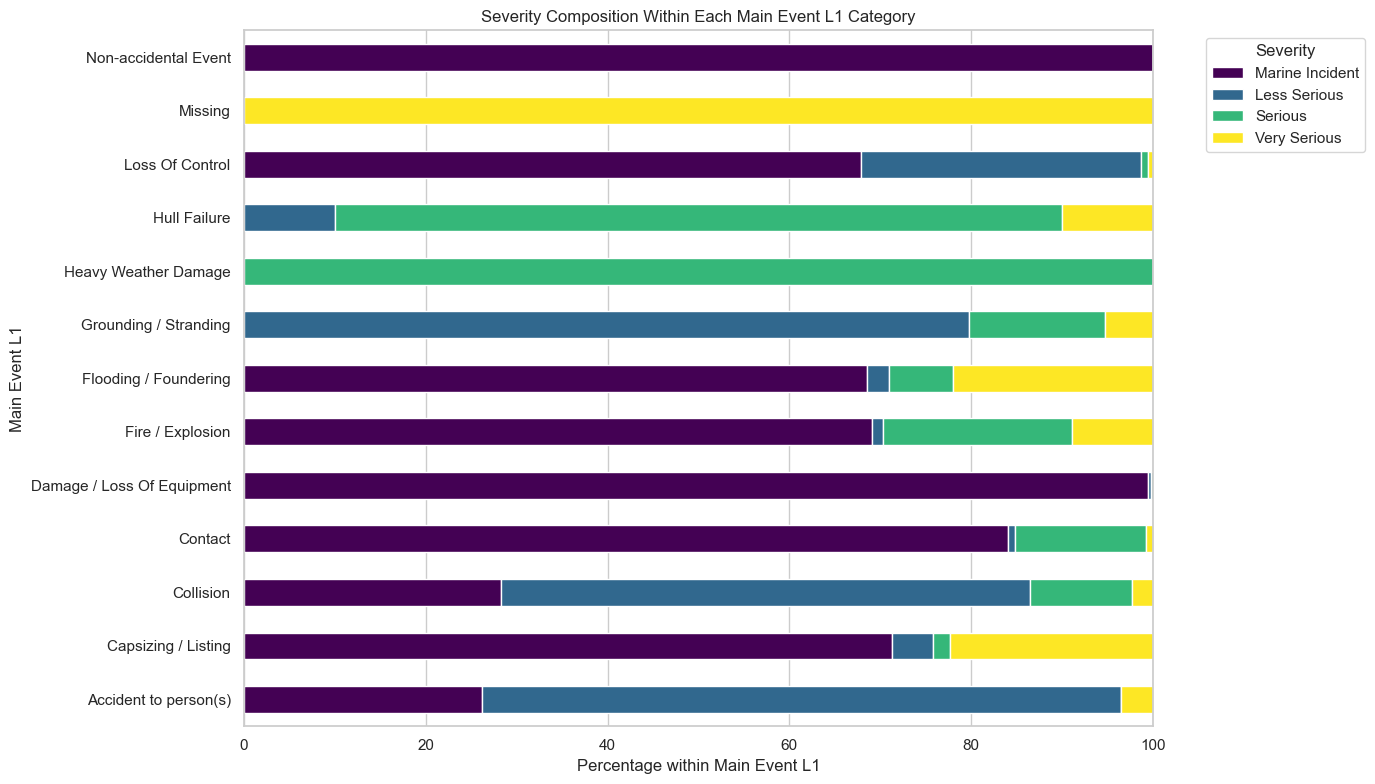

In [19]:
# -----------------------------
# 15. PLOT: SEVERITY MIX BY MAIN EVENT L1
# -----------------------------
severity_l1_pivot = severity_l1_pct.pivot(
    index="main_event_l1",
    columns="occurrence_severity",
    values="pct_within_l1"
).fillna(0)

severity_order = ["Marine Incident", "Less Serious", "Serious", "Very Serious"]
severity_l1_pivot = severity_l1_pivot.reindex(columns=[c for c in severity_order if c in severity_l1_pivot.columns])

severity_l1_pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 8),
    colormap="viridis"
)
plt.title("Severity Composition Within Each Main Event L1 Category")
plt.xlabel("Percentage within Main Event L1")
plt.ylabel("Main Event L1")
plt.legend(title="Severity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [20]:
# -----------------------------
# 16. MOST SEVERE EVENT GROUPS
# -----------------------------
serious_mix = severity_l1_pct[
    severity_l1_pct["occurrence_severity"].isin(["Serious", "Very Serious"])
].copy()

serious_summary = (
    serious_mix.groupby("main_event_l1")["pct_within_l1"]
    .sum()
    .reset_index(name="serious_or_very_serious_pct")
    .sort_values("serious_or_very_serious_pct", ascending=False)
)

print("\n===== EVENT GROUPS WITH HIGHEST SERIOUS / VERY SERIOUS SHARE =====")
print(serious_summary)


===== EVENT GROUPS WITH HIGHEST SERIOUS / VERY SERIOUS SHARE =====
                 main_event_l1  serious_or_very_serious_pct
8         Heavy Weather Damage                   100.000000
11                     Missing                   100.000000
9                 Hull Failure                    90.000000
5             Fire / Explosion                    29.653680
6        Flooding / Foundering                    29.054054
1          Capsizing / Listing                    24.203822
7        Grounding / Stranding                    20.207852
3                      Contact                    15.156250
2                    Collision                    13.498099
0        Accident to person(s)                     3.485930
10             Loss Of Control                     1.341282
4   Damage / Loss Of Equipment                     0.261780


In [21]:
# -----------------------------
# 17. TOP L2 CATEGORIES INSIDE TOP L1 GROUPS
# -----------------------------
top_l1_names = l1_counts.head(5)["main_event_l1"].tolist()

subset_top_l1 = df[df["main_event_l1"].isin(top_l1_names)].dropna(subset=["main_event_l2"])

top_l2_in_top_l1 = (
    subset_top_l1
    .groupby(["main_event_l1", "main_event_l2"])
    .size()
    .reset_index(name="count")
    .sort_values(["main_event_l1", "count"], ascending=[True, False])
)

print("\n===== TOP L2 INSIDE TOP 5 L1 GROUPS =====")
print(top_l2_in_top_l1.groupby("main_event_l1").head(5))


===== TOP L2 INSIDE TOP 5 L1 GROUPS =====
           main_event_l1                main_event_l2  count
2                Contact                 Shore Object    505
0                Contact              Floating Object    131
1                Contact                Flying Object      2
4  Grounding / Stranding                        Power    609
3  Grounding / Stranding                        Drift    225
8        Loss Of Control     Loss Of Propulsion Power    959
6        Loss Of Control  Loss Of Directional Control    170
7        Loss Of Control     Loss Of Electrical Power    118
5        Loss Of Control          Loss Of Containment     93


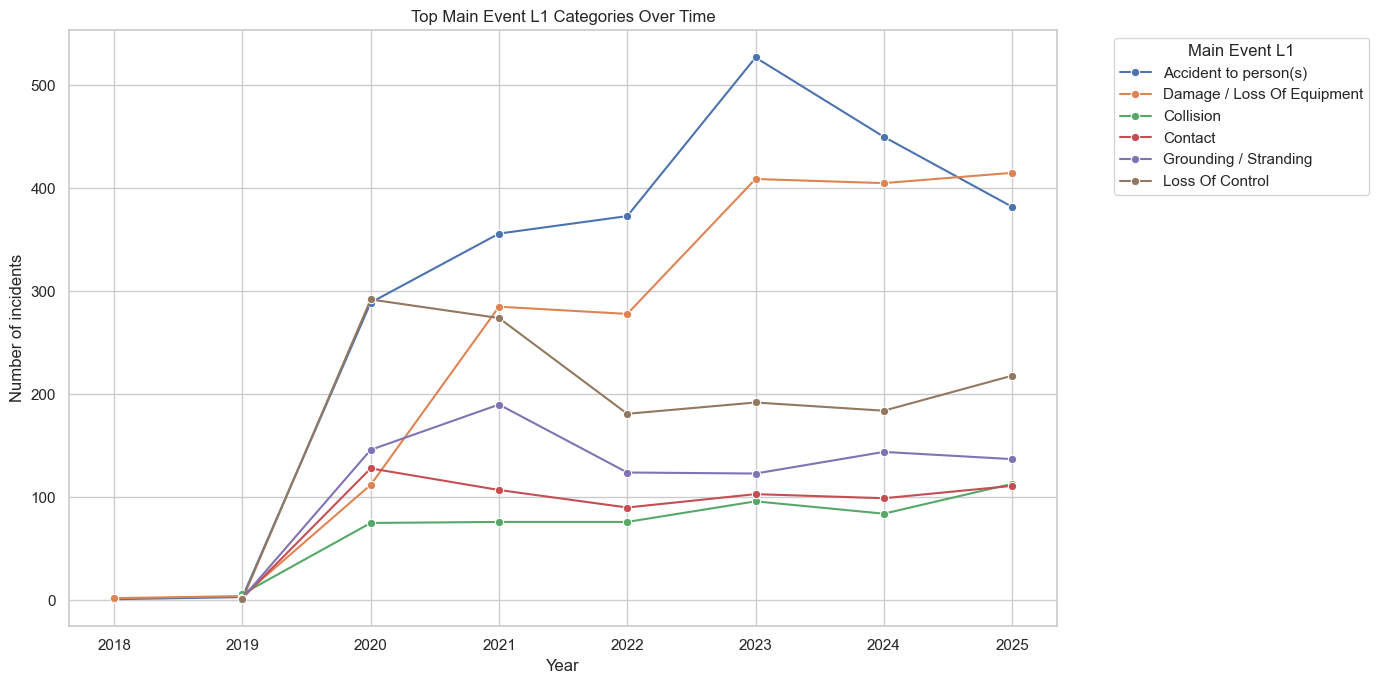

In [22]:
# -----------------------------
# 18. L1 CATEGORIES OVER TIME
# -----------------------------
l1_by_year = (
    df.dropna(subset=["event_year", "main_event_l1"])
    .groupby(["event_year", "main_event_l1"])
    .size()
    .reset_index(name="count")
)

top_l1_for_trend = l1_counts.head(6)["main_event_l1"].tolist()
l1_by_year_top = l1_by_year[l1_by_year["main_event_l1"].isin(top_l1_for_trend)]

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=l1_by_year_top,
    x="event_year",
    y="count",
    hue="main_event_l1",
    marker="o"
)
plt.title("Top Main Event L1 Categories Over Time")
plt.xlabel("Year")
plt.ylabel("Number of incidents")
plt.legend(title="Main Event L1", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Valid L1 groups for Cell 19:
           main_event_l1  total_rows  unique_l2  unique_years
6        Loss Of Control        1340          4             7
5  Grounding / Stranding         834          2             7
2                Contact         638          3             7
1              Collision         524          3             7
3       Fire / Explosion         458          2             6
4  Flooding / Foundering         296          2             6
0    Capsizing / Listing         156          2             6

Selected Main Event L1 for plotting: Loss Of Control

Filtered L2-by-year table:
    event_year                main_event_l2  count
0         2019     Loss Of Propulsion Power      1
1         2020          Loss Of Containment     19
2         2020  Loss Of Directional Control     32
3         2020     Loss Of Electrical Power     27
4         2020     Loss Of Propulsion Power    214
5         2021          Loss Of Containment      7
6         2021  Loss Of Directional 

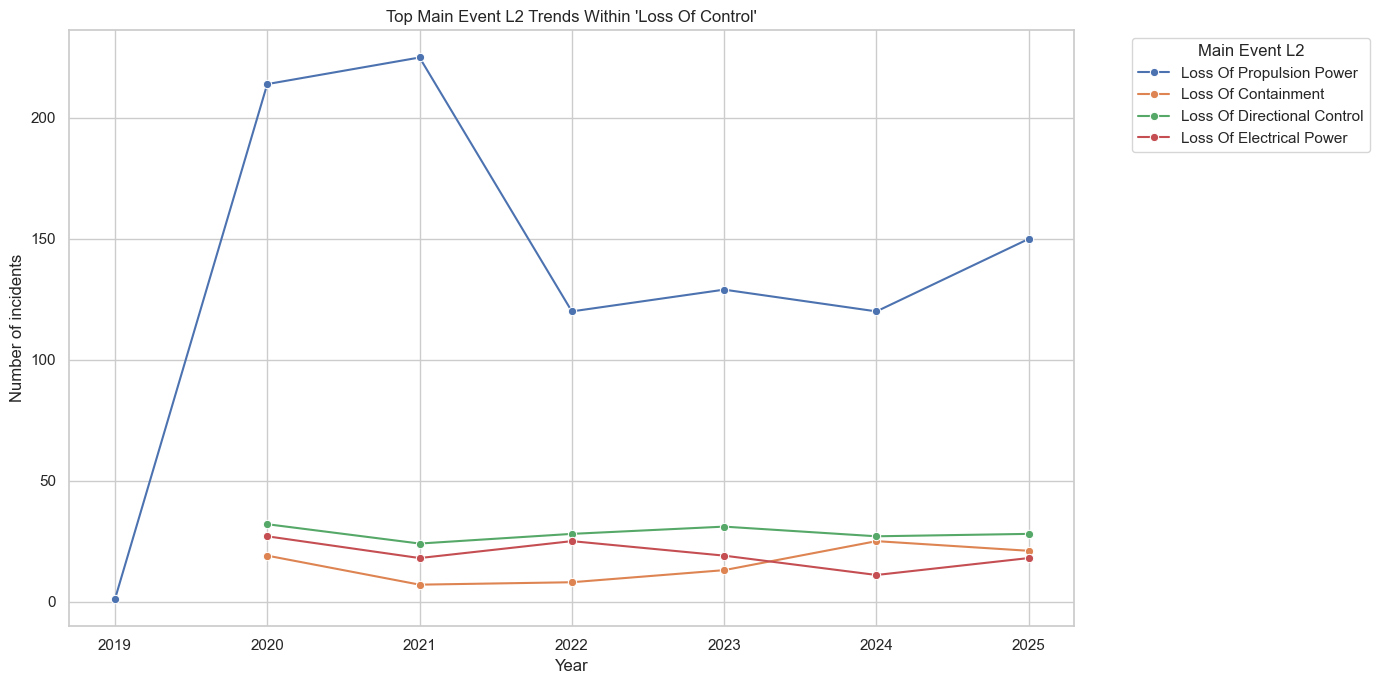

In [29]:
# -----------------------------
# 19. L2 CATEGORIES OVER TIME FOR A VALID L1 GROUP
# -----------------------------

# Step 1: find L1 categories that actually have usable L2 + year data
valid_l1 = (
    df.dropna(subset=["main_event_l1", "main_event_l2", "event_year"])
      .groupby("main_event_l1")
      .agg(
          total_rows=("main_event_l2", "size"),
          unique_l2=("main_event_l2", "nunique"),
          unique_years=("event_year", "nunique")
      )
      .reset_index()
)

# keep only categories with enough structure to plot
valid_l1 = valid_l1[
    (valid_l1["unique_l2"] >= 2) &
    (valid_l1["unique_years"] >= 2) &
    (valid_l1["total_rows"] >= 10)
].sort_values(["total_rows", "unique_l2"], ascending=False)

print("Valid L1 groups for Cell 19:")
print(valid_l1.head(10))

if valid_l1.empty:
    print("No suitable Main Event L1 category has enough L2-by-year data to plot.")
else:
    # pick the best available category automatically
    focus_l1 = valid_l1.iloc[0]["main_event_l1"]
    print(f"\nSelected Main Event L1 for plotting: {focus_l1}")

    # Step 2: build L2-by-year trend table
    focus_l2_by_year = (
        df[
            (df["main_event_l1"] == focus_l1) &
            (df["main_event_l2"].notna()) &
            (df["event_year"].notna())
        ]
        .groupby(["event_year", "main_event_l2"])
        .size()
        .reset_index(name="count")
    )

    # Step 3: keep top 5 L2 categories by total count
    top_focus_l2 = (
        focus_l2_by_year.groupby("main_event_l2")["count"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .index
    )

    focus_l2_by_year = focus_l2_by_year[
        focus_l2_by_year["main_event_l2"].isin(top_focus_l2)
    ].copy()

    print("\nFiltered L2-by-year table:")
    print(focus_l2_by_year.head(20))

    if focus_l2_by_year.empty:
        print(f"No plottable L2 trend data available for '{focus_l1}'.")
    else:
        plt.figure(figsize=(14, 7))
        ax = sns.lineplot(
            data=focus_l2_by_year,
            x="event_year",
            y="count",
            hue="main_event_l2",
            marker="o"
        )

        plt.title(f"Top Main Event L2 Trends Within '{focus_l1}'")
        plt.xlabel("Year")
        plt.ylabel("Number of incidents")

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            plt.legend(title="Main Event L2", bbox_to_anchor=(1.05, 1), loc="upper left")

        plt.tight_layout()
        plt.show()

In [30]:
# -----------------------------
# 20. SUMMARY INSIGHTS
# -----------------------------
top_l1 = l1_counts.iloc[0]["main_event_l1"]
top_l1_count = int(l1_counts.iloc[0]["count"])

top_l2 = l2_counts.iloc[0]["main_event_l2"]
top_l2_count = int(l2_counts.iloc[0]["count"])

top_l3 = l3_counts.iloc[0]["main_event_l3"] if len(l3_counts) > 0 else "Not available"
top_l3_count = int(l3_counts.iloc[0]["count"]) if len(l3_counts) > 0 else 0

highest_serious_group = serious_summary.iloc[0]["main_event_l1"]
highest_serious_share = serious_summary.iloc[0]["serious_or_very_serious_pct"]

print("===== PART 2 SUMMARY INSIGHTS =====")
print(f"1. The most common broad incident family is '{top_l1}' with {top_l1_count} incidents.")
print(f"2. The most common level-2 subtype is '{top_l2}' with {top_l2_count} incidents.")
print(f"3. The most common level-3 subtype is '{top_l3}' with {top_l3_count} incidents.")
print(f"4. The event family with the highest combined Serious/Very Serious share is '{highest_serious_group}' at {highest_serious_share:.2f}%.")
print("5. The heatmaps and trend plots show how subtype composition varies across event families and over time.")

===== PART 2 SUMMARY INSIGHTS =====
1. The most common broad incident family is 'Accident to person(s)' with 2381 incidents.
2. The most common level-2 subtype is 'Loss Of Propulsion Power' with 959 incidents.
3. The most common level-3 subtype is 'Progressive' with 198 incidents.
4. The event family with the highest combined Serious/Very Serious share is 'Heavy Weather Damage' at 100.00%.
5. The heatmaps and trend plots show how subtype composition varies across event families and over time.
